In [15]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from Capricho.analysis import (
    DroppingComment,
    explode_assay_comparability,
    get_all_comments,
    plot_multi_panel_comparability,
    plot_subset,
)
from Capricho.core.pandas_helper import filter_dropping_flags

## Fetch CYP data

To fetch the data, we use the CLI with the following parameters:
```bash
capricho get --target-ids CHEMBL340,CHEMBL289,CHEMBL3397,CHEMBL3622,CHEMBL3356,CHEMBL2722,CHEMBL1908,CHEMBL3379,CHEMBL3978,CHEMBL4878,CHEMBL2231,CHEMBL3721,CHEMBL5282,CHEMBL4729 \
    --drop-unassigned-chiral --chirality --min-assay-size 5 --max-assay-size 100 \
    --assay-types A,B,F --id-columns standard_type --output-path cyp_chembl_data.csv
```

In [17]:
from pathlib import Path

DATA_DIR = Path("data/cyp")
DATA_DIR.mkdir(exist_ok=True, parents=True)

DATA_FILE = DATA_DIR / "cyp_chembl_data.csv"

if not DATA_FILE.exists():
    ! capricho get --target-ids CHEMBL340,CHEMBL289,CHEMBL3397,CHEMBL3622,CHEMBL3356,CHEMBL2722,CHEMBL1908,CHEMBL3379,CHEMBL3978,CHEMBL4878,CHEMBL2231,CHEMBL3721,CHEMBL5282,CHEMBL4729 \
        --drop-unassigned-chiral --chirality --min-assay-size 5 --max-assay-size 100 \
        --assay-types A,B,F --id-columns standard_type --output-path {str(DATA_FILE)}
else:
    print(f"Data already exists: {DATA_FILE}")
    print("Delete this file to re-fetch with updated parameters.")

Data already exists: data/cyp/cyp_chembl_data.csv
Delete this file to re-fetch with updated parameters.


# Cross-Assay Comparability

In [18]:
df = pd.read_csv(DATA_FILE, engine="pyarrow")
subset = df.query('processed_smiles.str.contains("|", regex=False)').assign(repeat=lambda x: range(len(x)))
subset.shape

(10742, 39)

In [19]:
df.standard_type.value_counts()

standard_type
AC50       39259
IC50       19187
Potency    15530
EC50         868
Ki           798
Kd            25
ED50           1
Name: count, dtype: int64

In [20]:
df.data_processing_comment.apply(
    lambda x: x.split("|") if isinstance(x, str) else []
).explode().value_counts()

data_processing_comment
                                                               21874
Salt/solvent removed                                            2768
pChEMBL Duplication Across Documents                            2235
Salt/solvent removed & pChEMBL Duplication Across Documents       18
Name: count, dtype: int64

In [21]:
all_comments = get_all_comments()
exploded_subset = explode_assay_comparability(subset)

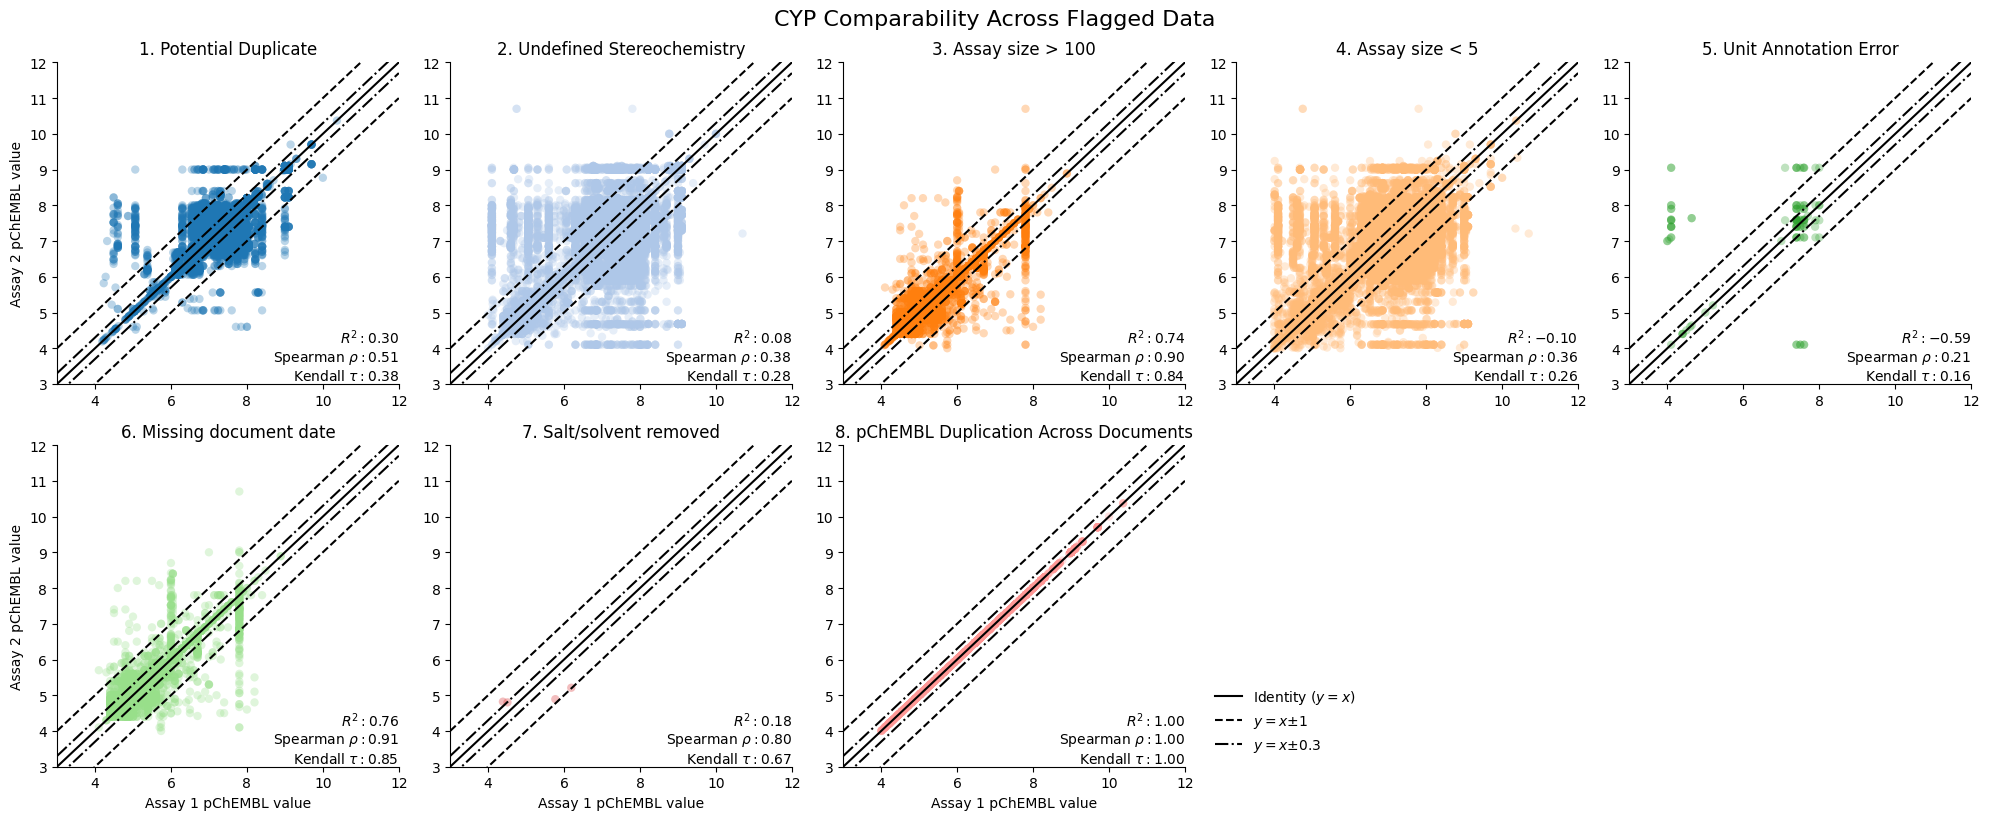

In [22]:
fig, axs = plot_multi_panel_comparability(
    exploded_subset, all_comments, title="CYP Comparability Across Flagged Data", figsize=(20, 8), ncols=5
)

fig.savefig("cyp_flagged_comparability.png", dpi=300, bbox_inches="tight", transparent=False)

## Unprocessed Data

2026-02-11 15:15:37 | INFO     | Capricho.core.pandas_helper:filter_dropping_flags:43 - Filtering 15652 rows with flag: 'Potential Duplicate'
2026-02-11 15:15:37 | INFO     | Capricho.core.pandas_helper:filter_dropping_flags:47 - Total rows filtered out: 15652/23640 (66.2%)


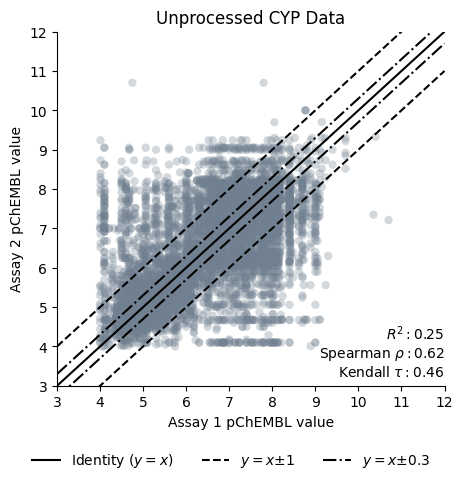

In [23]:
unprocessed = filter_dropping_flags(
    exploded_subset.query("pchembl_value_x != pchembl_value_y"),
    [DroppingComment.DATA_VALIDITY_COMMENT, DroppingComment.POTENTIAL_DUPLICATE],
    column="dropping_comment",
)

fig, ax = plot_subset(unprocessed, title="Unprocessed CYP Data", figsize=(5, 4.6))
fig.savefig("cyp_unprocessed_comparability.png", dpi=300, bbox_inches="tight", transparent=False)

# Cleaned Data

2026-02-11 15:15:37 | INFO     | Capricho.core.pandas_helper:filter_dropping_flags:43 - Filtering 2017 rows with flag: 'Unit Annotation Error'
2026-02-11 15:15:37 | INFO     | Capricho.core.pandas_helper:filter_dropping_flags:43 - Filtering 15654 rows with flag: 'Undefined Stereochemistry'
2026-02-11 15:15:37 | INFO     | Capricho.core.pandas_helper:filter_dropping_flags:43 - Filtering 17898 rows with flag: 'Assay size <'
2026-02-11 15:15:37 | INFO     | Capricho.core.pandas_helper:filter_dropping_flags:47 - Total rows filtered out: 20601/23640 (87.1%)


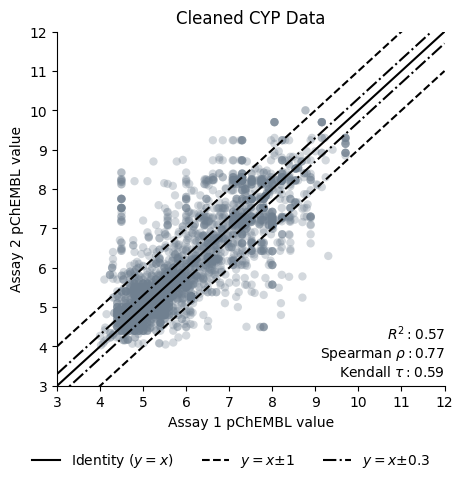

In [24]:
cleaned = filter_dropping_flags(
    exploded_subset.query("pchembl_value_x != pchembl_value_y"),
    [
        DroppingComment.UNIT_ANNOTATION_ERROR,
        DroppingComment.UNDEFINED_STEREOCHEMISTRY,
        DroppingComment.ASSAY_SIZE_TOO_SMALL,
    ],
    column="dropping_comment",
)

fig, ax = plot_subset(cleaned, title="Cleaned CYP Data", figsize=(5, 4.6))
fig.savefig("cyp_cleaned_comparability.png", dpi=300, bbox_inches="tight", transparent=False)

## Prepare data for multitask modeling

The `capricho prepare` command filters quality flags and pivots the data into an activity
matrix (compounds × tasks) ready for multitask ML. Like `capricho get`, the underlying
functions can be called directly from Python.

**Option 1** — CLI:
```bash
capricho prepare -i cyp_chembl_data.csv -o cyp_activity_matrix.csv \
    --task-col target_chembl_id --id-columns standard_type \
    --drop-unit-error --drop-undefined-stereo --drop-assay-size
```

**Option 2** — Python API (used below): import `clean_data` and `prepare_multitask_data` directly.

In [25]:
from Capricho.cli.prepare import clean_data, prepare_multitask_data

cleaned = clean_data(
    df,
    drop_flags=[
        DroppingComment.UNIT_ANNOTATION_ERROR.value,
        DroppingComment.UNDEFINED_STEREOCHEMISTRY.value,
        DroppingComment.ASSAY_SIZE_TOO_SMALL.value,
    ],
    deduplicate=True,
)

activity_matrix = prepare_multitask_data(
    df=cleaned,
    task_col="target_chembl_id",
    value_col="pchembl_value_mean",
    compound_col="smiles",
    smiles_col="smiles",
    id_columns=["standard_type"],
)
activity_matrix.head(1)

activity_matrix.to_csv("cyp_activity_matrix.csv", index=False)

2026-02-11 15:15:37 | INFO     | Capricho.cli.prepare:clean_data:88 - Deduplicating identical values within aggregated rows...
2026-02-11 15:15:39 | INFO     | Capricho.cli.prepare:clean_data:96 - Deduplication removed 9037 duplicate values
2026-02-11 15:15:39 | INFO     | Capricho.cli.prepare:clean_data:98 - Recalculating statistics after deduplication...
/Users/davidararipe/micromamba/envs/capricho/lib/python3.10/site-packages/numpy/_core/_methods.py:223: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
2026-02-11 15:15:46 | INFO     | Capricho.analysis:filter_aggregated_dropping_flags:293 - Rows with flag 'Unit Annotation Error': 176
2026-02-11 15:15:46 | INFO     | Capricho.analysis:filter_aggregated_dropping_flags:293 - Rows with flag 'Undefined Stereochemistry': 11169
2026-02-11 15:15:46 | INFO     | Capricho.analysis:filter_aggregated_dropping_flags:293 - Rows with flag 'Assay size <': 4238
2026-02-11 15:15:47 | INFO  

In [26]:
from Capricho.chembl.api.downloader import get_target_names_sql
import seaborn as sns

target_ids = [c.split("-")[0] for c in activity_matrix.columns if c.startswith("CHEMBL")]
target_names = get_target_names_sql(target_ids)
df["target_name"] = df["target_chembl_id"].map(target_names)
df.columns = [
    target_names[c.split("-")[0]] + c.split("-")[1] if c.startswith("CHEMBL") else c for c in df.columns
]
# df.target_name = df.target_name.apply(lambda x: x.split(",")[0])

df["target_activ_type"] = df["target_name"] + "-" + df["standard_type"]
tasks = df["target_activ_type"].unique().tolist()


_keep = df.target_activ_type.value_counts() >= 100
filtered_tasks = [t for t in tasks if _keep[t]]

result = (
    df.query("target_activ_type in @filtered_tasks")
    .pivot_table(
        index=["connectivity", "smiles"],
        columns="target_activ_type",
        values="pchembl_value_mean",
        aggfunc="first",  # or 'mean' if you have multiple values per combination
    )
    .reset_index()
)

### Filter activity sets

After running the cleaning and preparation steps, we remove activity sets with fewer than 100 compounds (see part with query for < 100 compounds below)

In [27]:
from Capricho.chembl.api.downloader import get_target_names_sql
import seaborn as sns

target_ids = [c.split("-")[0] for c in activity_matrix.columns if c.startswith("CHEMBL")]
target_names = get_target_names_sql(target_ids)
activity_matrix.columns = [
    target_names[c.split("-")[0]] + " - " + c.split("-")[1] if c.startswith("CHEMBL") else c
    for c in activity_matrix.columns
]
task_cols = [c for c in activity_matrix.columns if c not in ["smiles", "connectivity"]]

n_datapoints = activity_matrix[task_cols].notna().sum()
drop_tasks = n_datapoints[n_datapoints < 100].index.tolist()
filtered_task_cols = [c for c in task_cols if c not in drop_tasks]

activity_matrix.to_csv("cyp_activity_matrix.csv", index=False)

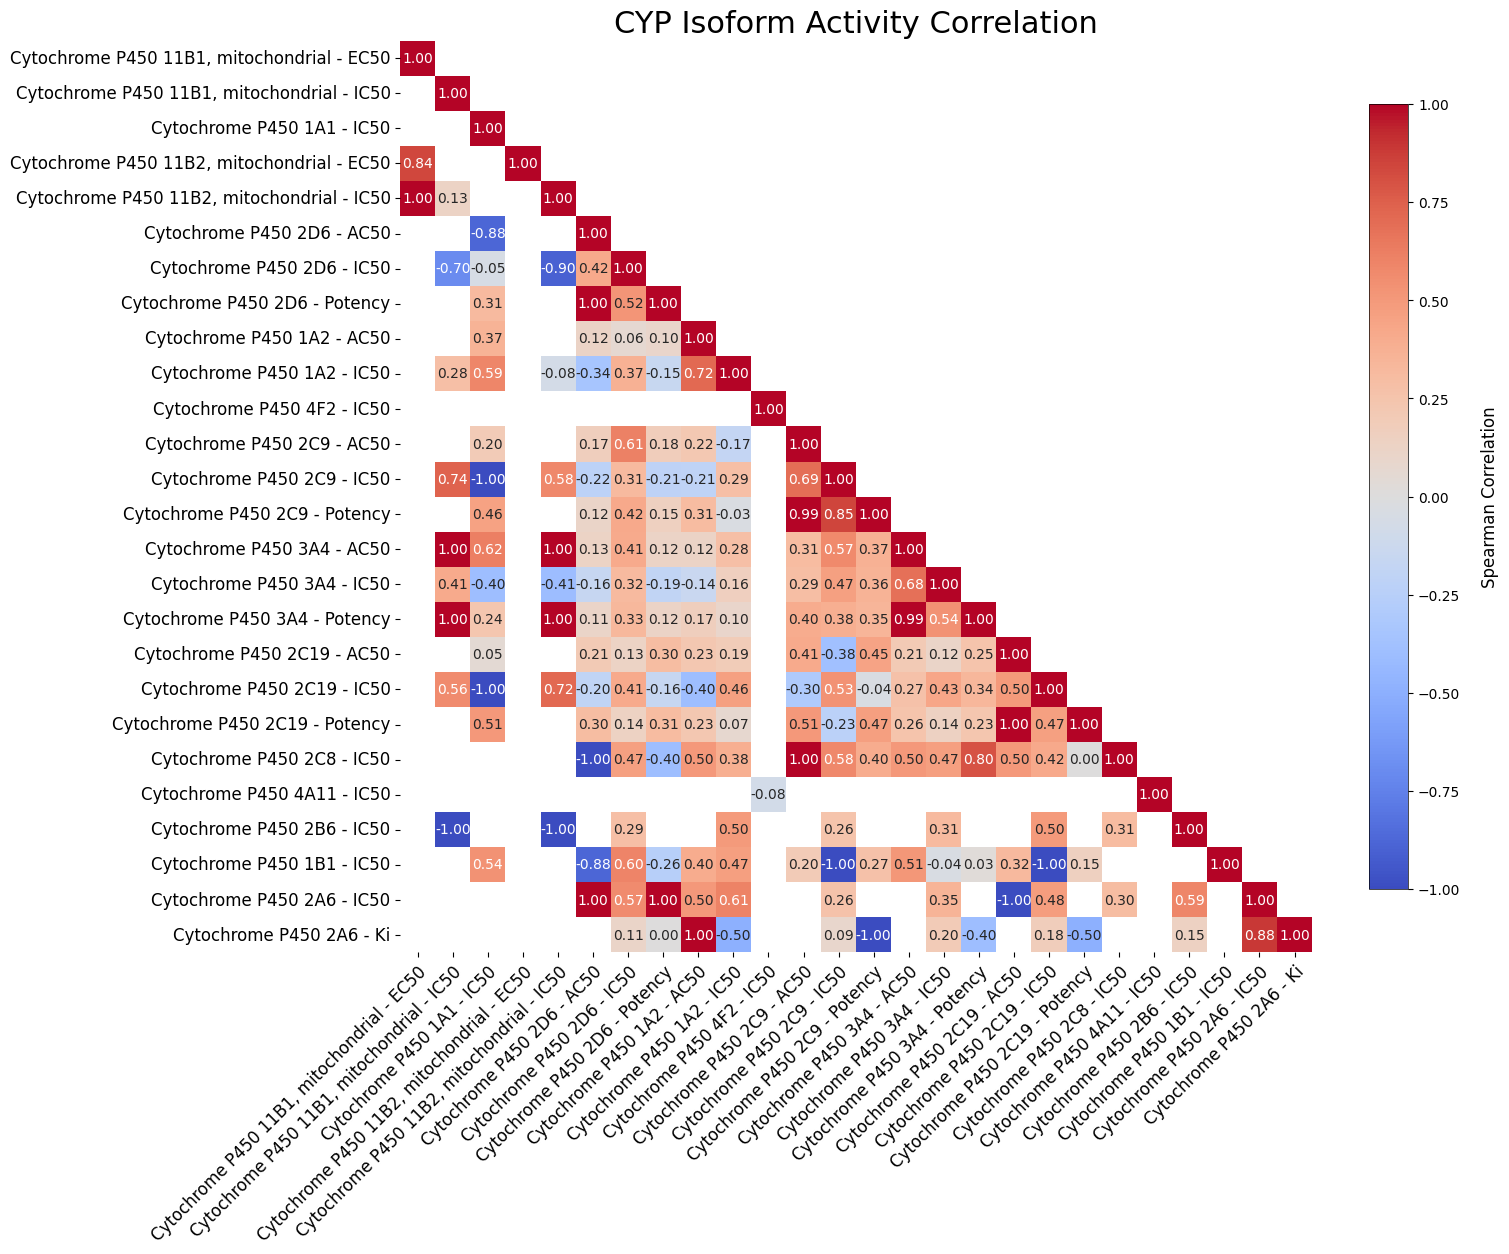

In [28]:
corr_matrix = activity_matrix[filtered_task_cols].corr(method="spearman")

figsize = (max(10, len(filtered_task_cols) * 0.6), max(8, len(filtered_task_cols) * 0.5))
fig, ax = plt.subplots(figsize=figsize)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

heatmap = sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    ax=ax,
    annot=True,
    fmt=".2f",
    mask=mask,
    square=True,
    cbar_kws={"shrink": 0.8},
)

cbar = heatmap.collections[0].colorbar
cbar.outline.set_edgecolor("black")
cbar.outline.set_linewidth(0.5)
cbar.set_label("Spearman Correlation", labelpad=15, fontsize=12)

plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor", fontsize=12)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=12)

ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("CYP Isoform Activity Correlation", fontsize=22)

fig.tight_layout()
fig.savefig("cyp_activity_correlation_matrix.png", dpi=300, bbox_inches="tight", transparent=False)
plt.show()